In [2]:
import os
import random
import re
import sys
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import savgol_filter, find_peaks
from scipy.stats import pointbiserialr
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss, confusion_matrix
)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from tqdm.notebook import tqdm

keypoints_labels = [
    "head", "nose", "neck", "rightShoulder", "rightElbow", "rightWrist",
    "leftShoulder", "leftElbow", "leftWrist", "rightHip", "rightKnee", "rightAnkle",
    "leftHip", "leftKnee", "leftAnkle", "rightFoot", "leftFoot"
]
feature_names = ["head horizontal", "head vertical", "weight_shift", "knee bending", "trunk straightening", "trunk rocking", "trunk throwing", "arm throwing", "arm shaking", "arm rocking", "arm straightening", "shoulder shaking"]
df_union = pd.read_csv("csvs/df_union.csv")
df_majority = pd.read_csv("csvs/df_majority.csv")

In [4]:
# Base path to the CSV files
base_path = "data_final_experiment/gap/maj/"

# Define the variants and modalities
sets = [
    "three_twelve",
    "quarter_twelve",
    # "thirty_twelve",
    "five_twelve",
    "ten_twelve"]
modalities = ["sna", "swa", "sao"]

# Dictionary to store the loaded DataFrames
dataset_gap_ff = {}

# Load each CSV into the dictionary
for s in sets:
    for m in modalities:
        key = f"{m}_{s}"
        file_path = f"{base_path}{key}_gap.csv"
        dataset_gap_ff[key] = pd.read_csv(file_path)

In [5]:
def has_none(*arrays):
    """
    Checks if any of the input arrays is None or contains NaN values.

    Returns:
    --------
    bool
        True if any array is None or contains NaNs; otherwise False.
    """
    return any(arr is None or np.any(pd.isnull(arr)) for arr in arrays)


def single_distance(j: np.ndarray) -> np.ndarray:
    """
    Computes absolute frame-wise differences in a 1D signal.

    Parameters:
    -----------
    j : np.ndarray
        1D array of joint measurements.

    Returns:
    --------
    np.ndarray
        Absolute frame-to-frame differences.
    """
    return np.abs(np.diff(j))


def compute_distance(j1: np.ndarray, j2: np.ndarray) -> np.ndarray:
    """
    Computes Euclidean distance between two joint trajectories.

    If j2 is None, returns norm of j1 as is (e.g., relative to origin).

    Parameters:
    -----------
    j1, j2 : np.ndarray
        Arrays of shape (frames, dimensions) or (frames, 2).

    Returns:
    --------
    np.ndarray
        Array of distances per frame.
    """
    v = j1 if j2 is None else j1 - j2
    diff = map(lambda x: np.linalg.norm(x, axis=0), v)
    return np.array(list(diff))


def compute_speed(j: np.ndarray) -> np.ndarray:
    """
    Computes per-frame joint speed using finite differences and smoothing.

    Parameters:
    -----------
    j : np.ndarray
        Array of shape (frames, 2) or (frames, N), representing joint positions.

    Returns:
    --------
    np.ndarray
        Smoothed speed per frame.
    """
    speed = np.diff(j, axis=0, prepend=j[0:1]) * 60  # Assume 60 FPS
    window_length = min(len(speed) if len(speed) % 2 == 1 else len(speed) - 1, 41)

    if window_length < 5:
        return speed  # Skip filtering for very short signals

    return savgol_filter(speed, window_length=window_length, polyorder=3)


def normalize_vector(v: np.ndarray) -> np.ndarray:
    """
    Normalizes a vector to range [0, 1].

    Parameters:
    -----------
    v : np.ndarray

    Returns:
    --------
    np.ndarray
        Normalized vector or zero vector if range is 0.
    """
    v_min = np.min(v)
    v_range = np.max(v) - v_min
    return (v - v_min) / v_range if v_range > 0 else np.zeros_like(v)


def threshold_check(value: float, t: float, f: float = 0.2) -> float:
    """
    Soft thresholding function: returns 0 below t, linear rise to 1 over [t, t + t*f].

    Parameters:
    -----------
    value : float
        Input value to evaluate.
    t : float
        Hard threshold.
    f : float
        Fuzzy range relative to t (default: 20%).

    Returns:
    --------
    float
        Score between 0 and 1.
    """
    if value < t:
        return 0.0
    elif value < t + t * f:
        return (value - t) / (t * f)
    else:
        return 1.0


def range_check(value: float, r1: float, r2: float, f: float = 0.1) -> float:
    """
    Fuzzy membership in [r1, r2] with tolerance margins on both ends.

    Parameters:
    -----------
    value : float
        Value to test.

    r1, r2 : float
        Lower and upper bounds of the target range.

    f : float
        Tolerance as a fraction of (r2 - r1).

    Returns:
    --------
    float
        Score between 0 and 1.
    """
    if value < r1 or value > r2:
        return 0.0
    if value < r1 + (r2 - r1) * f:
        return (value - r1) / ((r2 - r1) * f)
    if value > r2 - (r2 - r1) * f:
        return (r2 - value) / ((r2 - r1) * f)
    return 1.0


def frequency_check(signal: np.ndarray, fps: int, f1: float, f2: float, scale: float = 0.3) -> float:
    """
    Estimates frequency of prominent peaks in a 1D signal and checks if it falls in [f1, f2] Hz.

    Parameters:
    -----------
    signal : np.ndarray
        1D input signal (e.g., distance or speed curve).

    fps : int
        Frames per second.

    f1, f2 : float
        Expected frequency range in Hz.

    scale : float
        Multiplier for dynamic prominence threshold (default: 0.3 × std deviation).

    Returns:
    --------
    float
        A score between 0 and 1 indicating match to expected frequency range.
    """
    if len(signal) < 3:
        return 0.0

    dynamic_prominence = np.std(signal) * scale
    if dynamic_prominence < 1e-6:
        return 0.0  # flat signal, no meaningful peaks

    peaks, _ = find_peaks(signal, prominence=dynamic_prominence)
    if len(peaks) < 2:
        return 0.0

    duration_seconds = len(signal) / fps
    freq = len(peaks) / duration_seconds

    return range_check(freq, f1, f2, f=0.2)


In [6]:
def f1_head_horizontal(head: np.ndarray, nose: np.ndarray, neck: np.ndarray) -> (float, float):
    """
    Feature 1: Horizontal head movement variance (head and nose relative to neck, x-axis).
    """
    if has_none(head, nose, neck): return 0.0, 1
    head_x = np.array([x[0] for x in head])
    nose_x = np.array([x[0] for x in nose])
    neck_x = np.array([x[0] for x in neck])
    var_head = np.var(np.abs(head_x - neck_x))
    var_nose = np.var(np.abs(nose_x - neck_x))
    return (var_head + var_nose) * 0.5, 0


def f2_head_vertical(head: np.ndarray, nose: np.ndarray, neck: np.ndarray) -> (float, float):
    """
    Feature 2: Vertical head movement variance (head and nose relative to neck, y-axis).
    """
    if has_none(head, nose, neck): return 0.0, 1
    head_y = np.array([x[1] for x in head])
    nose_y = np.array([x[1] for x in nose])
    neck_y = np.array([x[1] for x in neck])
    var_head = np.var(np.abs(head_y - neck_y))
    var_nose = np.var(np.abs(nose_y - neck_y))
    return (var_head + var_nose) * 0.5, 0


def f3_weight_shift(right_hip: np.ndarray, left_hip: np.ndarray, right_foot: np.ndarray, left_foot: np.ndarray) -> (float, float):
    """
    Feature 3: Weight shifting — variance of proportion of foot distances to pelvis.
    """
    if has_none(right_hip, left_hip, right_foot, left_foot): return 0.0, 1
    pelvis = 0.5 * (right_hip + left_hip)
    d1 = compute_distance(pelvis, right_foot)
    d2 = compute_distance(pelvis, left_foot)
    final = d1 / (d1 + d2 + 1e-6)  # Avoid division by zero
    return np.var(final), 0


def f4_knee_bending(r_ankle, r_knee, r_hip, l_ankle, l_knee, l_hip) -> (float, float):
    """
    Feature 4: Knee bending symmetry (based on triangle inequality over hip-knee-ankle joints).
    """
    if has_none(r_ankle, r_knee, r_hip, l_ankle, l_knee, l_hip): return 0.0, 1

    def side_bending(ankle, knee, hip):
        d1 = compute_distance(knee, hip)
        d2 = compute_distance(ankle, knee)
        d3 = compute_distance(ankle, hip)
        return d3 / (d1 + d2 + 1e-6)

    f_right = side_bending(r_ankle, r_knee, r_hip)
    f_left = side_bending(l_ankle, l_knee, l_hip)
    combined = f_right + f_left
    return np.mean(combined), 0


def f6_trunk_straightening(neck, right_hip, left_hip) -> (float, float):
    """
    Feature 6: Trunk straightening — variance of normalized neck-to-pelvis distance.
    """
    if has_none(neck, right_hip, left_hip): return 0.0, 1
    pelvis = 0.5 * (right_hip + left_hip)
    return np.var(normalize_vector(compute_distance(neck, pelvis))), 0


def f7_trunk_rocking(neck, right_hip, left_hip) -> (float, float):
    """
    Feature 7: Trunk rocking — frequency of oscillations in neck-pelvis distance speed.
    """
    if has_none(neck, right_hip, left_hip): return 0.0, 1
    pelvis = 0.5 * (right_hip + left_hip)
    distance = compute_distance(neck, pelvis)
    speed = compute_speed(distance)
    return frequency_check(speed, 60, 0.5, 2), 0


def f8_trunk_throwing(neck, right_hip, left_hip) -> (float, float):
    """
    Feature 8: Trunk throwing — mean normalized speed of trunk motion exceeding threshold.
    """
    if has_none(neck, right_hip, left_hip): return 0.0, 1
    pelvis = 0.5 * (right_hip + left_hip)
    distance = compute_distance(neck, pelvis)
    speed = compute_speed(distance)
    speed = normalize_vector(speed)
    return threshold_check(np.mean(speed), 0.15, 0.35), 0


def f9_f10_f11_arm(left_hip, right_hip, right_hand, left_hand) -> (float, float, float, float):
    """
    Features 9, 10, 11: Arm throwing, shaking, and rocking based on speed and frequency of hand motion.

    Returns:
        throwing_score, shaking_score, rocking_score, nan_flag
    """
    if has_none(right_hip, left_hip, right_hand, left_hand): return 0.0, 0.0, 0.0, 1
    pelvis = 0.5 * (right_hip + left_hip)

    def side_comp(pelvis, hand):
        d1 = compute_distance(pelvis, hand)
        speed = compute_speed(d1)
        nsp = normalize_vector(speed)
        throwing = threshold_check(np.mean(nsp), 0.6, 0.33)
        shaking = frequency_check(speed, 60, 1.5, 5.5)
        rocking = frequency_check(speed, 60, 0.5, 2)
        return throwing, shaking, rocking

    l_throwing, l_shaking, l_rocking = side_comp(pelvis, left_hand)
    r_throwing, r_shaking, r_rocking = side_comp(pelvis, right_hand)
    return l_throwing + r_throwing, l_shaking + r_shaking, l_rocking + r_rocking, 0


def f12_arm_straightening(rs, re, rh, ls, le, lh) -> (float, float):
    """
    Feature 12: Arm straightening — variance of triangle length consistency for both arms.

    Inputs:
        rs, re, rh — right shoulder, elbow, hand
        ls, le, lh — left shoulder, elbow, hand
    """
    if has_none(rs, re, rh, ls, le, lh): return 0.0, 1

    def side_comp(s, e, h):
        d1 = compute_distance(s, e)
        d2 = compute_distance(e, h)
        d3 = compute_distance(s, h)
        return d3 + (d1 + d2 + 1e-6)  # pseudo-ratio

    r = side_comp(rs, re, rh)
    l = side_comp(ls, le, lh)
    return np.var(r + l), 0


def f13_shoulder_shaking(ls: np.ndarray, rs: np.ndarray) -> (float, float):
    """
    Feature 13: Shoulder shaking — frequency of lateral shoulder movement.
    """
    if has_none(ls, rs): return 0.0, 1
    # Pick one shoulder — logic unclear, possibly bug?
    shoulder = rs if None in ls[0] else ls
    d = compute_distance(shoulder, None)
    n = normalize_vector(d)
    n = np.array(list(n))
    return frequency_check(n, 60, 1.5, 5.5), 0


In [7]:
def decolumnized_keypoints(keypoints):
    """
    Converts serialized or nested keypoint entries into structured 17x2 numpy arrays,
    and returns a DataFrame where each row is a dictionary mapping joint labels to arrays.

    Parameters:
    -----------
    keypoints : iterable
        Each item is either a string or a 17x2 array representing joint positions.

    Returns:
    --------
    pd.DataFrame
        DataFrame where each column corresponds to a joint name and each entry is a (x, y) tuple or None.
    """
    rows = []
    for r in keypoints:
        if isinstance(r, str):
            # Extract numbers and 'None' from string
            tokens = re.findall(r'None|[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', r)
            values = [float(t) if t != 'None' else None for t in tokens]

            if len(values) != 34:
                print("OPAAAAAAAAAAAAAAAAAA")
                print(values)
                print(f"⚠️ Bad row: expected 34 values, got {len(values)}")
                print(r)
                continue

            r = np.array(values, dtype=object).reshape(17, 2)

        row = dict(zip(keypoints_labels, r))  # Create a row mapping joint name to 2D keypoint
        rows.append(row)

    return pd.DataFrame(rows)
def create_dataset(df, segments):
    """
    Generates feature vectors and labels from a set of motion segments using keypoint-based movement features.

    Parameters:
    -----------
    df : pd.DataFrame
        Frame-level keypoint data with columns including ['video_id', 'agent_id', 'frame_id'] and joints.

    segments : pd.DataFrame
        Segment definitions including ['video_id', 'agent_id', 'start_frame', 'end_frame', 'label'].

    Returns:
    --------
    xs : list of list
        Extracted feature vectors for each segment.

    ys : list of int
        Labels (0 or 1) corresponding to each segment.

    agent_ids : list of int
        Agent ID for each segment.

    percentages : dict
        Dictionary indicating percentage of segments with missing data for each feature.

    means : list of float
        Mean value for each feature (ignores missing).
    """
    xs, ys, agent_ids = [], [], []

    # Track how many times each feature failed (a=1 from feature fn means bad input)
    nan_counts = {f"f{i}": 0 for i in [1, 2, 3, 4, 6, 7, 8, 9, 12, 13]}

    df = df.sort_values(["video_id", "agent_id", "frame_id"]).reset_index(drop=True)
    grouped = df.groupby(["video_id", "agent_id"])

    keypoints = [
        "head", "nose", "neck", "rightShoulder", "rightElbow", "rightWrist",
        "leftShoulder", "leftElbow", "leftWrist", "rightHip", "rightKnee", "rightAnkle",
        "leftHip", "leftKnee", "leftAnkle"
    ]

    for seg in tqdm(segments.itertuples(index=False), total=len(segments),
                    desc="Processing segments", file=sys.stdout):
        vid, agent, start, end, label = seg.video_id, seg.agent_id, seg.start_frame, seg.end_frame, seg.label

        # Retrieve the relevant rows for this segment
        try:
            group_df = grouped.get_group((vid, agent))
        except KeyError:
            continue  # Skip if group is missing

        frames = group_df[(group_df["frame_id"] >= start) & (group_df["frame_id"] <= end)]

        if frames.empty:
            continue

        # Create a dictionary of joint arrays: keypoint name → (frames, 2)
        keypoint_arrays = {k: np.stack(frames[k].values) for k in keypoints}

        # Compute features
        f1, f1a = f1_head_horizontal(keypoint_arrays["head"], keypoint_arrays["nose"], keypoint_arrays["neck"])
        f2, f2a = f2_head_vertical(keypoint_arrays["head"], keypoint_arrays["nose"], keypoint_arrays["neck"])
        f3, f3a = f3_weight_shift(keypoint_arrays["rightHip"], keypoint_arrays["leftHip"],
                                  keypoint_arrays["rightAnkle"], keypoint_arrays["leftAnkle"])
        f4, f4a = f4_knee_bending(keypoint_arrays["rightHip"], keypoint_arrays["rightKnee"], keypoint_arrays["rightAnkle"],
                                  keypoint_arrays["leftHip"], keypoint_arrays["leftKnee"], keypoint_arrays["leftAnkle"])
        f6, f6a = f6_trunk_straightening(keypoint_arrays["neck"], keypoint_arrays["rightHip"], keypoint_arrays["leftHip"])
        f7, f7a = f7_trunk_rocking(keypoint_arrays["neck"], keypoint_arrays["rightHip"], keypoint_arrays["leftHip"])
        f8, f8a = f8_trunk_throwing(keypoint_arrays["neck"], keypoint_arrays["rightHip"], keypoint_arrays["leftHip"])
        f9, f10, f11, f9a = f9_f10_f11_arm(keypoint_arrays["leftHip"], keypoint_arrays["rightHip"],
                                          keypoint_arrays["rightWrist"], keypoint_arrays["leftWrist"])
        f12, f12a = f12_arm_straightening(keypoint_arrays["rightShoulder"], keypoint_arrays["rightElbow"], keypoint_arrays["rightWrist"],
                                          keypoint_arrays["leftShoulder"], keypoint_arrays["leftElbow"], keypoint_arrays["leftWrist"])
        f13, f13a = f13_shoulder_shaking(keypoint_arrays["rightShoulder"], keypoint_arrays["leftShoulder"])

        # Log missing feature data
        for k, a in zip([1, 2, 3, 4, 6, 7, 8, 9, 12, 13], [f1a, f2a, f3a, f4a, f6a, f7a, f8a, f9a, f12a, f13a]):
            nan_counts[f"f{k}"] += a

        # Append data
        xs.append([f1, f2, f3, f4, f6, f7, f8, f9, f10, f11, f12, f13])
        ys.append(label)
        agent_ids.append(agent)

    xs_np = np.array(xs)
    means = np.nanmean(xs_np, axis=0) if xs else [None] * 12
    n = len(segments)
    percentages = {k: nan_counts[k] / n if n else 0 for k in nan_counts}

    return xs, ys, agent_ids, percentages, means


In [76]:
 fdf = df_majority.drop(columns=['keypoints']).join(decolumnized_keypoints(df_majority['keypoints']))


In [9]:
def keypoint_displacement_features(keypoint_seq):
    """
    Computes motion-related features from a single keypoint's 2D trajectory.

    Parameters:
    -----------
    keypoint_seq : list or np.ndarray
        Sequence of (x, y) coordinates for a keypoint over time.

    Returns:
    --------
    dict
        Dictionary containing total displacement, mean speed, max speed, and speed variance.
        All values are 0 if the input is invalid or empty.
    """
    if has_none(keypoint_seq):
        return {
            "total_disp": 0,
            "mean_speed": 0,
            "max_speed": 0,
            "speed_var": 0,
        }

    arr = np.array(keypoint_seq)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError(f"Expected (n,2) shape, got {arr.shape}")

    dif = compute_distance(arr, None)       # Magnitude of position (if arr is relative to origin)
    speeds = compute_speed(dif)             # Frame-wise speed

    return {
        "total_disp": np.sum(speeds),
        "mean_speed": np.mean(speeds),
        "max_speed": np.max(speeds),
        "speed_var": np.var(speeds),
    }

def create_var_dataset(df, segments):
    """
    Generates a dataset of low-level motion features for each keypoint in each segment:
    total displacement, mean speed, max speed, and speed variance.

    Parameters:
    -----------
    df : pd.DataFrame
        Frame-level keypoint data with columns: ['video_id', 'agent_id', 'frame_id'] and 2D keypoints.

    segments : pd.DataFrame
        Segment metadata including: ['video_id', 'agent_id', 'start_frame', 'end_frame', 'label', 'length'].

    Returns:
    --------
    xs : list of list[float]
        Feature vectors (one per segment) of size 4 × number of keypoints.

    ys : list[int]
        Segment labels (e.g., laughter = 1, no laughter = 0).

    agent_ids : list[int]
        Agent ID for each segment.

    percentages : dict
        Placeholder for NaN tracking (not actively used in current implementation).

    means : np.ndarray or list[float]
        Mean value for each feature across the dataset.
    """
    xs, ys, agent_ids = [], [], []
    nan_counts = defaultdict(int)

    df = df.sort_values(["video_id", "agent_id", "frame_id"]).reset_index(drop=True)
    grouped = df.groupby(["video_id", "agent_id"])

    # Keypoints to process (15 × 4 features = 60 total per segment)
    keypoints = [
        "head", "nose", "neck", "rightShoulder", "rightElbow", "rightWrist",
        "leftShoulder", "leftElbow", "leftWrist", "rightHip", "rightKnee",
        "rightAnkle", "leftHip", "leftKnee", "leftAnkle"
    ]

    for vid, agent, start, end, label, length in tqdm(
        segments.itertuples(index=False),
        total=len(segments),
        desc="Processing segments",
        file=sys.stdout
    ):
        group_df = grouped.get_group((vid, agent))
        frames = group_df[(group_df["frame_id"] >= start) & (group_df["frame_id"] <= end)]

        if frames.empty:
            continue

        f_vec = []
        for k in keypoints:
            # Extract stacked (n_frames, 2) array for keypoint `k`
            kp = np.stack(frames[k].to_numpy(), axis=0)
            a = keypoint_displacement_features(kp)

            # Append 4 stats per keypoint
            f_vec.extend([
                a["total_disp"],
                a["mean_speed"],
                a["max_speed"],
                a["speed_var"]
            ])

        xs.append(f_vec)
        ys.append(label)
        agent_ids.append(agent)

    xs_np = np.array(xs)
    means = np.nanmean(xs_np, axis=0) if len(xs_np) > 0 else [None] * (4 * len(keypoints))
    n = len(segments)
    percentages = {k: nan_counts[k] / n if n else 0 for k in nan_counts}  # Not actively used

    return xs, ys, agent_ids, percentages, means


In [59]:
dataset_results_var = {}

# Loop through all segmented datasets (e.g., by modality or condition)
for name, segments in dataframes.items():
    print(f"Processing {name}")

    # Extract displacement/speed-based features
    xs, ys, agent_ids, nan_pct, mean_feats = create_var_dataset(fdf, segments)

    # Store features and labels in a dictionary for later use (e.g., training)
    dataset_results_var[name] = {
        "xs": xs,
        "ys": ys,
        "agent_ids": agent_ids,
    }

    # Collect diagnostic information for analysis/reporting
    diag = {"name": name}
    diag.update({f"nan_pct_{k}": v for k, v in nan_pct.items()})       # % of missing feature segments
    diag.update({f"mean_{i+1}": m for i, m in enumerate(mean_feats)})  # Mean of each feature

    diagnostics.append(diag)

# Save diagnostics summary to CSV
diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df.to_csv("data_final_experiment/feature_diagnostics.csv", index=False)


Processing sna_sixty_twelve


Processing segments:   0%|          | 0/12233 [00:00<?, ?it/s]

Processing swa_sixty_twelve


Processing segments:   0%|          | 0/7305 [00:00<?, ?it/s]

Processing sao_sixty_twelve


...

Processing segments:   0%|          | 0/8059 [00:00<?, ?it/s]

Processing swa_fifteen_twelve


Processing segments:   0%|          | 0/5087 [00:00<?, ?it/s]

Processing sao_fifteen_twelve


Processing segments:   0%|          | 0/5956 [00:00<?, ?it/s]

In [10]:
dataset_results_gap_ff = {}
# Loop through each dataset
for name, segments in dataset_gap_ff.items():
    print(f"Processing {name}")
    xs, ys, agent_ids, nan_pct, mean_feats = create_dataset(fdf, segments)

    dataset_results_gap_ff[name] = {
        "xs": xs,
        "ys": ys,
        "agent_ids": agent_ids,
    }



Processing sna_three_twelve


Processing segments:   0%|          | 0/1205 [00:00<?, ?it/s]

Processing swa_three_twelve


Processing segments:   0%|          | 0/978 [00:00<?, ?it/s]

Processing sao_three_twelve


...

Processing segments:   0%|          | 0/1016 [00:00<?, ?it/s]

Processing swa_ten_twelve


Processing segments:   0%|          | 0/886 [00:00<?, ?it/s]

Processing sao_ten_twelve


Processing segments:   0%|          | 0/1059 [00:00<?, ?it/s]

In [111]:
for name, dataset in dataset_results.items():
    dsdf = pd.DataFrame(dataset)
    dsdf.to_csv(f'model_training/df_union/gap/{name}.csv', index=False)


In [10]:
def print_correlation_between_feature_laughter(feature, label, feature_name):
    """
    Plots feature values and labels on the same timeline (index-based) for visual inspection.

    Parameters:
    -----------
    feature : list or array-like
        Numeric values of a single feature across samples.

    label : list or array-like
        Binary labels (e.g., laughter = 1, no laughter = 0).

    feature_name : str
        Descriptive name of the feature (used in the plot title).
    """
    x = list(range(len(feature)))
    plt.plot(x, feature, label='Feature Value')
    plt.plot(x, label, label='Label')

    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.title(f'Correlation between feature value and laughter annotation for {feature_name}')
    plt.legend()
    plt.show()

def print_correlation(feature, label, feature_name):
    """
    Computes and prints the point-biserial correlation between a numeric feature and a binary label.

    Parameters:
    -----------
    feature : list or array-like
        Feature values (continuous).

    label : list or array-like
        Binary labels (0 or 1).

    feature_name : str
        Name of the feature for print formatting.
    """
    corr, pval = pointbiserialr(label, feature)
    print(f'{feature_name} - Correlation: {corr:.3f}, p-value: {pval:.3e}')

def scatter_feature_vs_label(feature, label, feature_name):
    """
    Plots a scatterplot of feature values against binary labels.

    Parameters:
    -----------
    feature : list or array-like
        Feature values.

    label : list or array-like
        Binary labels (0 or 1).

    feature_name : str
        Title label for the plot.
    """
    plt.figure(figsize=(8, 4))
    plt.scatter(label, feature, alpha=0.3)
    plt.xlabel('Label')
    plt.ylabel('Feature Value')
    plt.title(f'Scatter of {feature_name} vs Laughter Label')
    plt.grid(True)
    plt.show()

def boxplot_feature_vs_label(feature, label, feature_name):
    """
    Plots a boxplot comparing feature distributions across the two label classes.

    Parameters:
    -----------
    feature : list or array-like
        Feature values.

    label : list or array-like
        Binary labels (0 or 1).

    feature_name : str
        Name of the feature used in plot title.
    """
    df = pd.DataFrame({'Feature': feature, 'Label': label})
    sns.boxplot(x='Label', y='Feature', data=df)
    plt.title(f'Boxplot of {feature_name} by Laughter Label')
    plt.grid(True)
    plt.show()


In [86]:
# xna = np.array(xna)
for name, s in dataset_results_gap.items():
    xna = np.array(s['xs'])
    yna = np.array(s['ys'])
    print(f"Statistics for {name}")
    for i in range(12):
        feature = xna[:, i]
        print(f"Feature {feature_names[i]}:")
        print_correlation(feature, yna, feature_names[i])
        # boxplot_feature_vs_label(feature, yna, feature_names[i])
        # print_correlation_between_feature_laughter(feature, yna, feature_names[i])
        # scatter_feature_vs_label(feature, yna, feature_names[i])

Statistics for sna_sixty_twelve
Feature head horizontal:
head horizontal - Correlation: -0.012, p-value: 2.437e-01
Feature head vertical:
head vertical - Correlation: -0.000, p-value: 9.859e-01
Feature weight_shift:
weight_shift - Correlation: 0.056, p-value: 1.376e-07
Feature knee bending:
knee bending - Correlation: 0.037, p-value: 5.925e-04
Feature trunk straightening:
trunk straightening - Correlation: 0.023, p-value: 3.523e-02
Feature trunk rocking:
trunk rocking - Correlation: 0.036, p-value: 7.253e-04
Feature trunk throwing:
trunk throwing - Correlation: 0.109, p-value: 1.350e-24
Feature arm throwing:
arm throwing - Correlation: 0.028, p-value: 9.287e-03
Feature arm shaking:
arm shaking - Correlation: 0.036, p-value: 7.366e-04
Feature arm rocking:
arm rocking - Correlation: 0.036, p-value: 8.768e-04
Feature arm straightening:
arm straightening - Correlation: -0.015, p-value: 1.548e-01
Feature shoulder shaking:
shoulder shaking - Correlation: 0.053, p-value: 8.971e-07
Statistics 

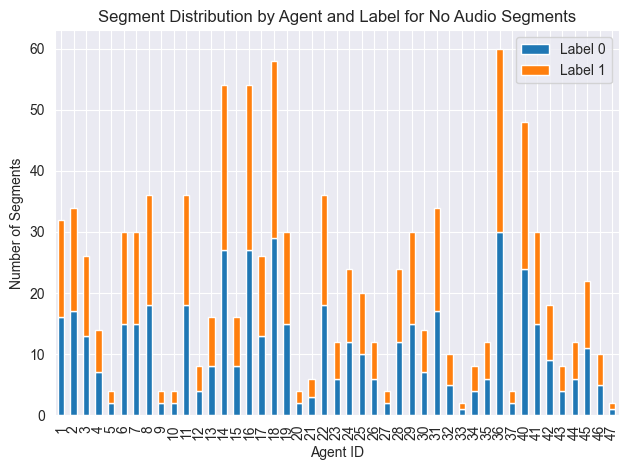

In [28]:
def visualize_num_of_segments(agents, y, label):
    """
    Plots a stacked bar chart showing the number of positive and negative segments per agent.

    Parameters:
    -----------
    agents : list or array-like
        Agent IDs corresponding to each segment.

    y : list or array-like
        Binary labels (e.g., 0 = no laughter, 1 = laughter) for each segment.

    label : str
        Title suffix to describe the dataset or condition (e.g., 'No Audio Segments').
    """
    # Create DataFrame of (agent_id, label) pairs
    df = pd.DataFrame({'agent_id': agents, 'label': y})

    # Count how many segments each agent has for each label
    counts = df.groupby(['agent_id', 'label']).size().unstack(fill_value=0)

    # Plot the stacked bar chart
    counts.plot(kind='bar', stacked=True)
    plt.xlabel("Agent ID")
    plt.ylabel("Number of Segments")
    plt.title(f"Segment Distribution by Agent and Label for {label}")
    plt.legend(["Label 0", "Label 1"])
    plt.tight_layout()
    plt.show()


In [65]:
def split_by_agent(x, y, agents, low, upper):
    """
    Splits the dataset into training and test sets by agent, ensuring the test set
    contains a total sample proportion within [low, upper] bounds.

    Parameters:
    -----------
    x : array-like
        Feature matrix.

    y : array-like
        Binary labels (same length as x).

    agents : array-like
        Agent identifiers (same length as x).

    low : float
        Minimum proportion of samples desired in the test set.

    upper : float
        Maximum proportion of samples allowed in the test set.

    Returns:
    --------
    x_train, y_train, agents_train : np.ndarray
        Training data, labels, and agents.

    x_test, y_test : np.ndarray
        Test data and labels.
    """
    x = np.array(x)
    y = np.array(y)
    agents = np.array(agents)

    unique_agents = list(np.unique(agents))

    # Compute per-agent laughter rate
    agent_pos_rate = {
        a: np.mean([y[i] for i in range(len(y)) if agents[i] == a]) for a in unique_agents
    }

    # Filter out agents with very few positive examples
    min_positive_rate = 0.05
    eligible_agents = [a for a in unique_agents if agent_pos_rate[a] >= min_positive_rate]

    selected_agents = []
    total_samples = len(x)
    current_ratio = 0.0

    random.shuffle(eligible_agents)  # Add randomness to selection

    # Incrementally add agents to test set until bounds are satisfied
    for agent in eligible_agents:
        agent_mask = agents == agent
        selected_count = np.sum(agent_mask)
        new_ratio = (current_ratio * total_samples + selected_count) / total_samples

        if new_ratio > upper:
            continue

        selected_agents.append(agent)
        current_ratio = new_ratio

        if current_ratio >= low:
            break

    # Construct boolean masks for indexing
    test_mask = np.isin(agents, selected_agents)
    train_mask = ~test_mask

    # Slice arrays accordingly
    x_train = x[train_mask]
    y_train = y[train_mask]
    agents_train = agents[train_mask]
    x_test = x[test_mask]
    y_test = y[test_mask]

    assert len(x_train) + len(x_test) == len(x)
    assert len(y_train) + len(y_test) == len(y)

    return x_train, y_train, agents_train, x_test, y_test

def save_plots(save_name, df_metrics, df_metrics_train, confusion_matrices, confusion_matrices_train, df_importances):
    """
    Saves diagnostic plots and averaged metrics/confusion matrices from multiple model runs.

    Parameters:
    -----------
    save_name : str
        Directory suffix to identify the result set.

    df_metrics : pd.DataFrame
        Performance metrics on test data across multiple runs.

    df_metrics_train : pd.DataFrame
        Performance metrics on train data across runs.

    confusion_matrices : list of np.ndarray
        Confusion matrices for each test run.

    confusion_matrices_train : list of np.ndarray
        Confusion matrices for each train run.

    df_importances : pd.DataFrame
        Feature importance values across runs (rows = runs, columns = features).
    """
    output_dir = f"model_training/charts/majority/{save_name}"
    os.makedirs(output_dir, exist_ok=True)

    # Boxplot of test metrics
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_metrics)
    plt.title(f"Performance Metrics over 10 Random Forest Runs for {label}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/accuracy.png", dpi=300)
    plt.close()

    # Boxplot of train metrics
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_metrics_train)
    plt.title(f"Performance Metrics over 10 Random Forest Runs for {label} on Train Data")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/accuracy_train.png", dpi=300)
    plt.close()

    # Mean and std plot for test metrics
    means = df_metrics.mean()
    stds = df_metrics.std()

    plt.figure(figsize=(10, 6))
    plt.errorbar(means.index, means.values, yerr=stds.values, fmt='o-', capsize=5)
    plt.title(f"Mean and Std Dev of Metrics over 10 Runs for {label}")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/mean_std.png", dpi=300)
    plt.close()

    # Feature importance bar plot
    importances_mean = df_importances.mean()
    importances_std = df_importances.std()
    feature_names = [
        "head horizontal", "head vertical", "weight_shift", "knee bending",
        "trunk straightening", "trunk rocking", "trunk throwing", "arm throwing",
        "arm shaking", "arm rocking", "arm straightening", "shoulder shaking"
    ]

    plt.figure(figsize=(10, 6))
    plt.bar(range(len(feature_names)), importances_mean, yerr=importances_std, capsize=5)
    plt.xticks(range(len(feature_names)), feature_names, rotation=75)
    plt.title(f"Average Feature Importances with Std Dev over 10 Runs for {label}")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/feature_importance.png", dpi=300)
    plt.show()
    plt.close()

    # Confusion matrix for test
    labels = ["Class 0", "Class 1"]
    avg_conf_matrix = np.mean(confusion_matrices, axis=0).astype(int)
    print("Average Confusion Matrix over 10 runs:\n", avg_conf_matrix)
    plt.figure(figsize=(6, 5))
    sns.heatmap(avg_conf_matrix, annot=True, fmt='d', cmap="Reds",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Averaged Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/conf_matrix_fold.png", dpi=300)
    plt.close()

    # Confusion matrix for train
    avg_conf_matrix_train = np.mean(confusion_matrices_train, axis=0).astype(int)
    print("Average Confusion Matrix over 10 runs on train data:\n", avg_conf_matrix_train)
    plt.figure(figsize=(6, 5))
    sns.heatmap(avg_conf_matrix_train, annot=True, fmt='d', cmap="Reds",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Averaged Confusion Matrix On Train Data")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/conf_matrix_fold_train.png", dpi=300)
    plt.close()

def plot_feature_importances(importances, feature_names, title="Feature Importances"):
    """
    Plot a bar chart of feature importances.

    Parameters:
    -----------
    importances : list or np.ndarray
        Importance values for each feature.

    feature_names : list of str
        Corresponding feature names.

    title : str
        Plot title.
    """
    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.bar(range(len(importances)), importances)
    plt.xticks(range(len(importances)), feature_names, rotation=80)
    plt.tight_layout()
    plt.show()


In [73]:
def train_model(x, y, agents, k, label, feature_names, save_name, feature_mask):
    """
    Train a Random Forest classifier over k runs with agent-disjoint test splits.
    Saves performance and feature importance plots.

    Parameters:
    -----------
    x : list of list
        Feature vectors.

    y : list of int
        Binary labels.

    agents : list
        Agent identifiers.

    k : int
        Number of random repetitions.

    label : str
        Label name for plot titles.

    feature_names : list of str
        Names of all features.

    save_name : str
        Output directory identifier for saved plots.

    feature_mask : list of int
        Indices of features to include (used for feature selection).

    Returns:
    --------
    metrics : dict
        Dictionary of performance metrics over k runs.
    """
    # Initialize metrics storage
    metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': [], 'AUC-ROC': [], 'AUC-PR': [], 'Log Loss': []}
    metrics_train = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': [], 'AUC-ROC': [], 'AUC-PR': [], 'Log Loss': []}
    confusion_matrices = []
    confusion_matrices_train = []
    feature_importances = []
    best_params_list = []

    # Replace NaNs in labels with 0
    y = [0 if np.isnan(a) else a for a in y]

    x = np.array(x)
    if len(feature_mask) > 0:
        x = [a[feature_mask] for a in x]

    i = 0
    best_f1 = -1
    best_acc = None
    best_config = None
    best_conf_matrix = None
    results = []

    # Repeat k training runs
    for _ in tqdm(range(k), desc=f"Processing Run {i}", file=sys.stdout):
        i += 1

        # Agent-disjoint split (roughly 30-33% in test set)
        x_train, y_train, agents_train, x_test, y_test = split_by_agent(x, y, agents, 0.3, 0.33)

        # Optional oversampling strategy (commented)
        # x_train, y_train = SMOTETomek().fit_resample(x_train, y_train)

        # Hyperparameter grid
        param_grid = {
            'n_estimators': [75, 100, 150],
            'max_depth': [5, 10, 20],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2, 3, 5, 10],
            'max_features': ['sqrt'],
            'bootstrap': [True, False],
            'criterion': ['log_loss'],
            'class_weight': ['balanced']
        }

        # Fit model using GridSearchCV
        clf = GridSearchCV(RandomForestClassifier(), param_grid, cv=10, scoring='neg_log_loss', n_jobs=-1)
        clf.fit(x_train, y_train)
        best_rf = clf.best_estimator_

        # Apply probability calibration
        clf = CalibratedClassifierCV(estimator=clf, method='sigmoid', cv=5)
        clf.fit(x_train, y_train)

        # Save feature importances
        feature_importances.append(best_rf.feature_importances_.tolist())

        # Predictions
        y_pred_train = clf.predict(x_train)
        y_proba_train = clf.predict_proba(x_train)[:, 1]
        y_pred = clf.predict(x_test)
        y_proba = clf.predict_proba(x_test)[:, 1]

        # Compute test metrics
        metrics['Accuracy'].append(accuracy_score(y_test, y_pred))
        metrics['Precision'].append(precision_score(y_test, y_pred, zero_division=0))
        metrics['Recall'].append(recall_score(y_test, y_pred))
        metrics['F1 Score'].append(f1_score(y_test, y_pred))
        metrics['AUC-ROC'].append(roc_auc_score(y_test, y_proba))
        metrics['AUC-PR'].append(average_precision_score(y_test, y_proba))
        metrics['Log Loss'].append(log_loss(y_test, y_proba))
        confusion_matrices.append(confusion_matrix(y_test, y_pred))

        # Compute train metrics
        metrics_train['Accuracy'].append(accuracy_score(y_train, y_pred_train))
        metrics_train['Precision'].append(precision_score(y_train, y_pred_train, zero_division=0))
        metrics_train['Recall'].append(recall_score(y_train, y_pred_train))
        metrics_train['F1 Score'].append(f1_score(y_train, y_pred_train))
        metrics_train['AUC-ROC'].append(roc_auc_score(y_train, y_proba_train))
        metrics_train['AUC-PR'].append(average_precision_score(y_train, y_proba_train))
        metrics_train['Log Loss'].append(log_loss(y_train, y_proba_train))
        confusion_matrices_train.append(confusion_matrix(y_train, y_pred_train))

    # Convert results to DataFrames
    df_metrics = pd.DataFrame(metrics)
    df_metrics_train = pd.DataFrame(metrics_train)
    df_importances = pd.DataFrame(feature_importances)

    # Save all visualizations and aggregate results
    save_plots(f"{save_name}", df_metrics, df_metrics_train, confusion_matrices, confusion_matrices_train, df_importances)

    return metrics

def params_to_str(params):
    """
    Convert a dictionary of parameters into a flattened string format.

    Example:
        {'n_estimators': 100, 'max_depth': 5}
        -> 'n_estimators-100_max_depth-5'

    Parameters:
    -----------
    params : dict
        Dictionary of hyperparameters.

    Returns:
    --------
    str
        Concatenated parameter string.
    """
    return "_".join(f"{k}-{v}" for k, v in params.items())


Processing Run 0:   0%|          | 0/10 [00:00<?, ?it/s]

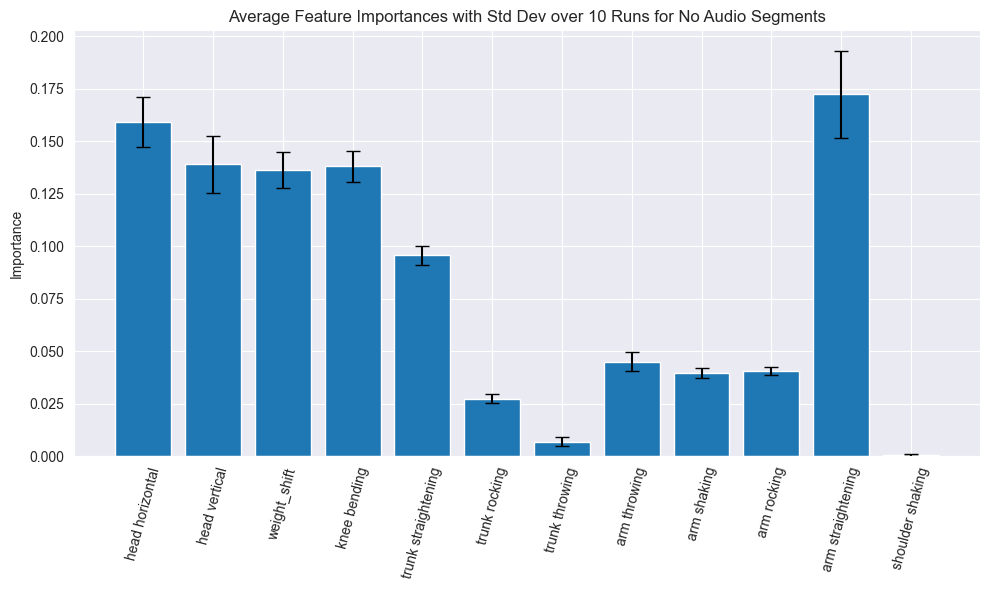

Average Confusion Matrix over 10 runs:
 [[133  53]
 [ 84 103]]
Average Confusion Matrix over 10 runs on train data:
 [[402  31]
 [ 58 338]]
Done


Processing Run 0:   0%|          | 0/10 [00:00<?, ?it/s]

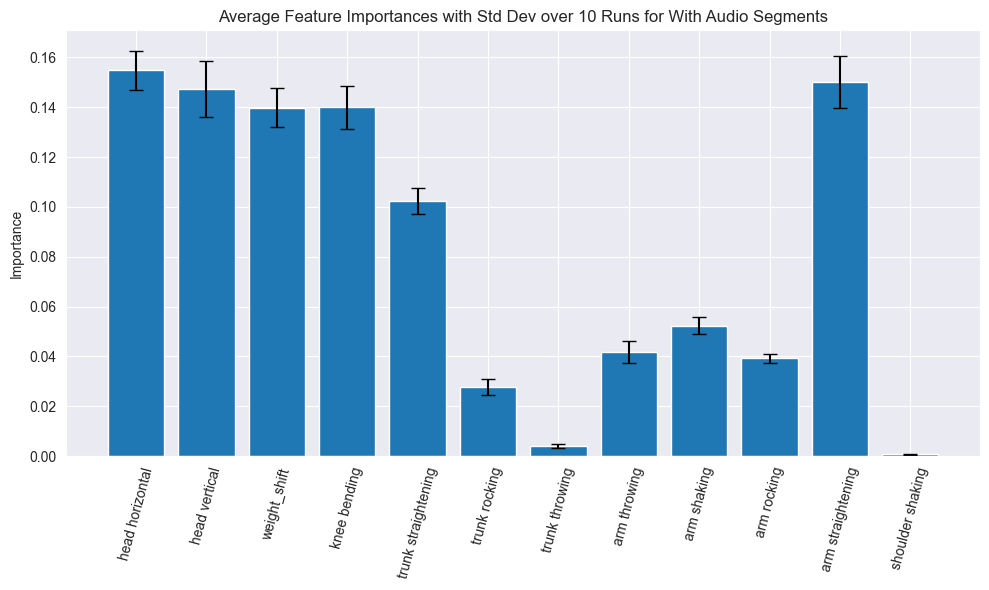

Average Confusion Matrix over 10 runs:
 [[97 53]
 [54 97]]
Average Confusion Matrix over 10 runs on train data:
 [[303  34]
 [ 20 316]]
Done


Processing Run 0:   0%|          | 0/10 [00:00<?, ?it/s]

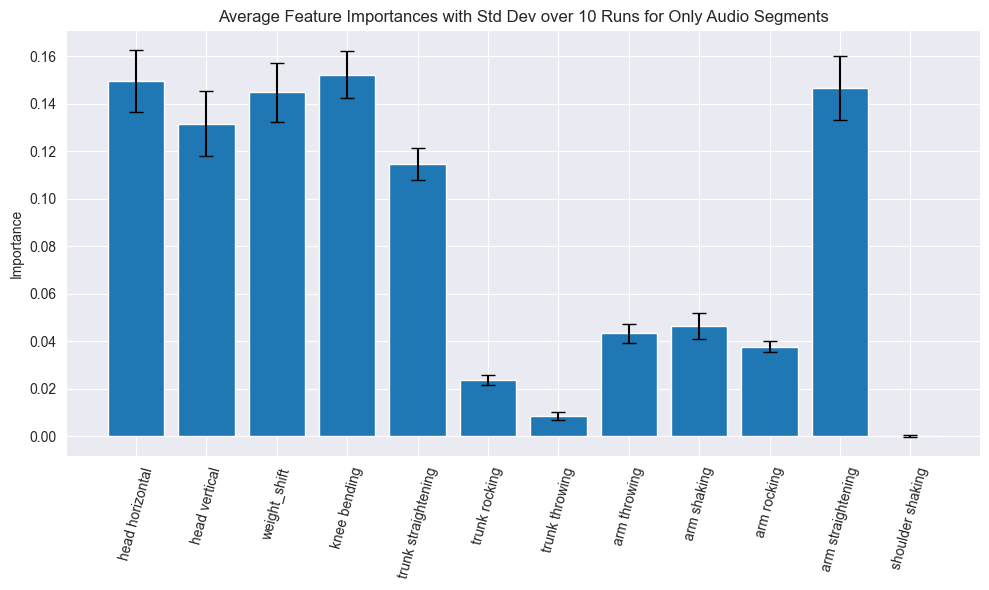

Average Confusion Matrix over 10 runs:
 [[98 70]
 [69 99]]
Average Confusion Matrix over 10 runs on train data:
 [[357  37]
 [ 29 328]]
Done


In [74]:
for n,d in dataset_results_gap_ff.items():
    s = dataset_results_gap_ff[n]
    if 'three' not in n: continue

    if "wa" in n:
        label = "With Audio Segments"
    elif "na" in n:
        label = "No Audio Segments"
    else:
        label = "Only Audio Segments"

    metrics = train_model(s['xs'], s['ys'], s['agent_ids'], 10, label, feature_names, f"{n}_ff_gs", [])
    print("Done")



Processing Run 0:   0%|          | 0/10 [00:00<?, ?it/s]

Average Confusion Matrix over 10 runs:
 [[136  55]
 [ 86 106]]
Average Confusion Matrix over 10 runs on train data:
 [[346  82]
 [128 263]]


Processing Run 0:   0%|          | 0/10 [00:00<?, ?it/s]

Average Confusion Matrix over 10 runs:
 [[136  52]
 [ 87 102]]
Average Confusion Matrix over 10 runs on train data:
 [[349  82]
 [142 252]]


Processing Run 0:   0%|          | 0/10 [00:00<?, ?it/s]

...

Processing Run 0:   0%|          | 0/10 [00:00<?, ?it/s]

Average Confusion Matrix over 10 runs:
 [[118  43]
 [ 90  74]]
Average Confusion Matrix over 10 runs on train data:
 [[315  78]
 [140 198]]


Processing Run 0:   0%|          | 0/10 [00:00<?, ?it/s]

Average Confusion Matrix over 10 runs:
 [[113  48]
 [ 96  69]]
Average Confusion Matrix over 10 runs on train data:
 [[316  77]
 [139 199]]
✅ Model training and metric collection complete.


Metric                         AUC-PR   AUC-ROC  Accuracy  F1 Score  Log Loss  \
Segment Type Feature Subset                                                     
No Audio     All Features    0.685543  0.684015  0.639158  0.618050  0.647893   
             Lower Body      0.613048  0.619489  0.587517  0.568669  0.677941   
             Upper Body      0.663425  0.662579  0.616366  0.590494  0.659256   
Only Audio   All Features    0.651803  0.663518  0.611830  0.579783  0.656908   
             Lower Body      0.604469  0.626124  0.587226  0.533176  0.674599   
             Upper Body      0.635064  0.648399  0.603987  0.564886  0.663418   
With Audio   All Features    0.657929  0.679556  0.630972  0.623200  0.647662   
             Lower Body      0.600954  0.628252  0.605776  0.620467  0.671233   
             Upper Body      0.653072  0.673867  0.623781  0.624880  0.651170   

Metric                       Precision    Recall  
Segment Type Feature Subset                       
No Audio     All Features     0.658785  0.588812  
             Lower Body       0.599019  0.552968  
             Upper Body       0.638200  0.556955  
Only Audio   All Features     0.633747  0.545170  
             Lower Body       0.623463  0.498786  
             Upper Body       0.628147  0.518854  
With Audio   All Features     0.636743  0.617819  
             Lower Body       0.598372  0.651931  
             Upper Body       0.622740  0.631617

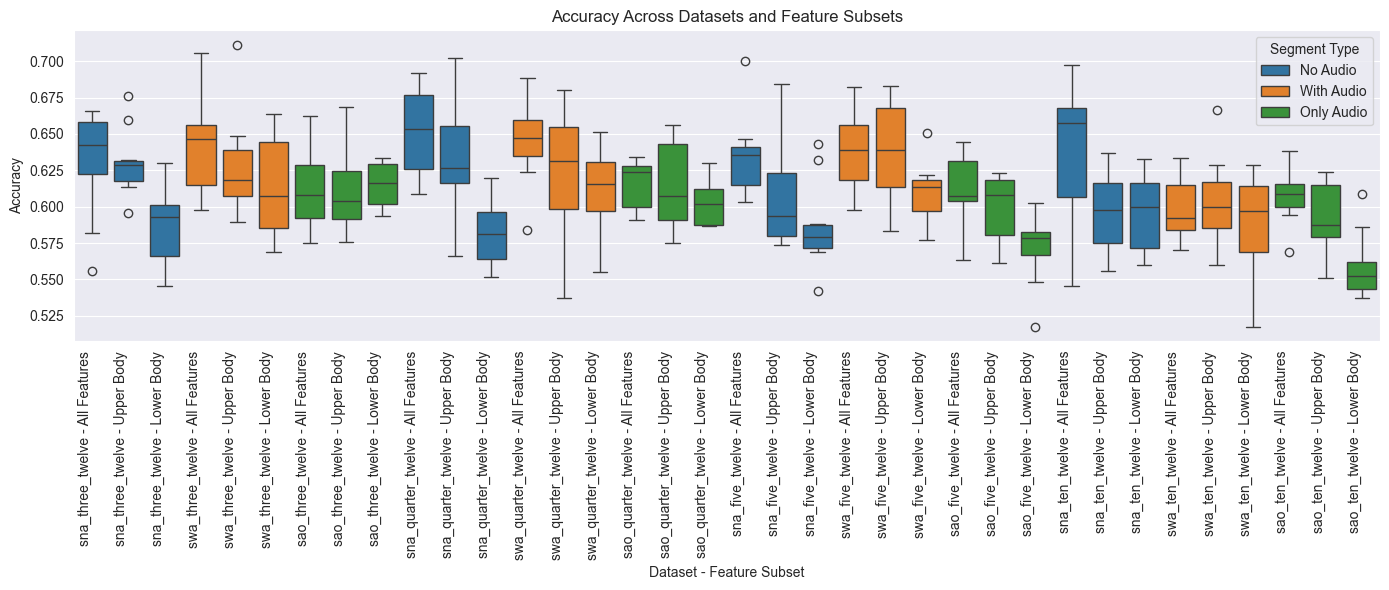

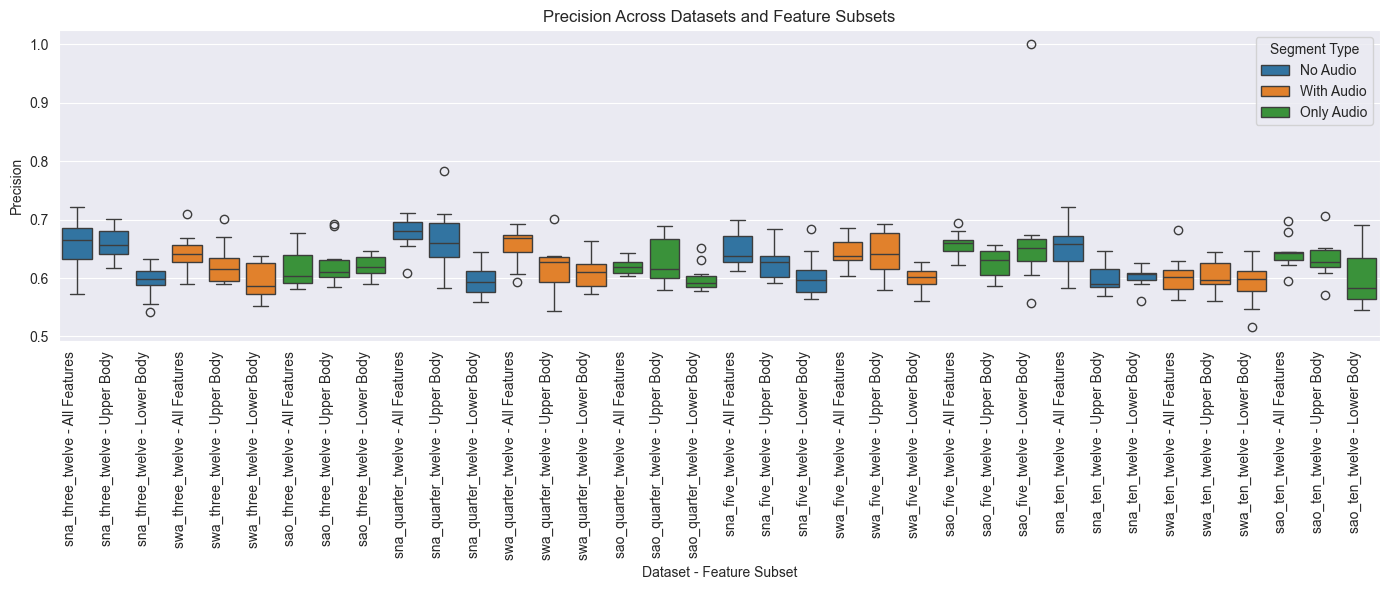

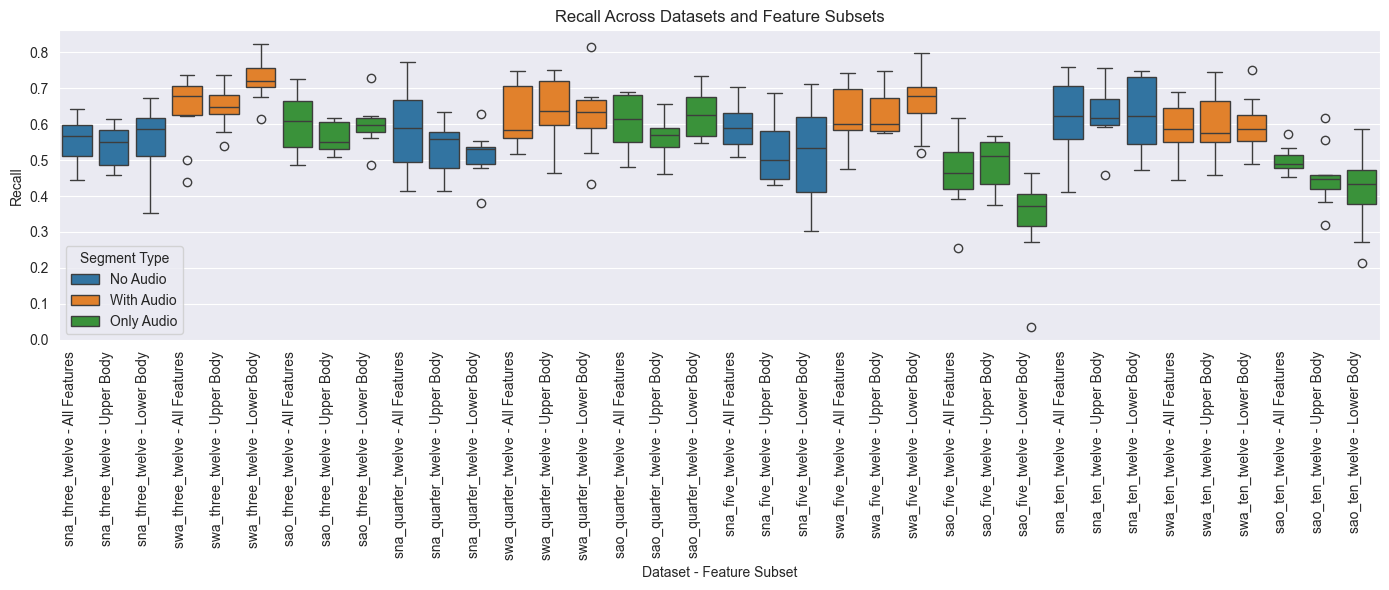

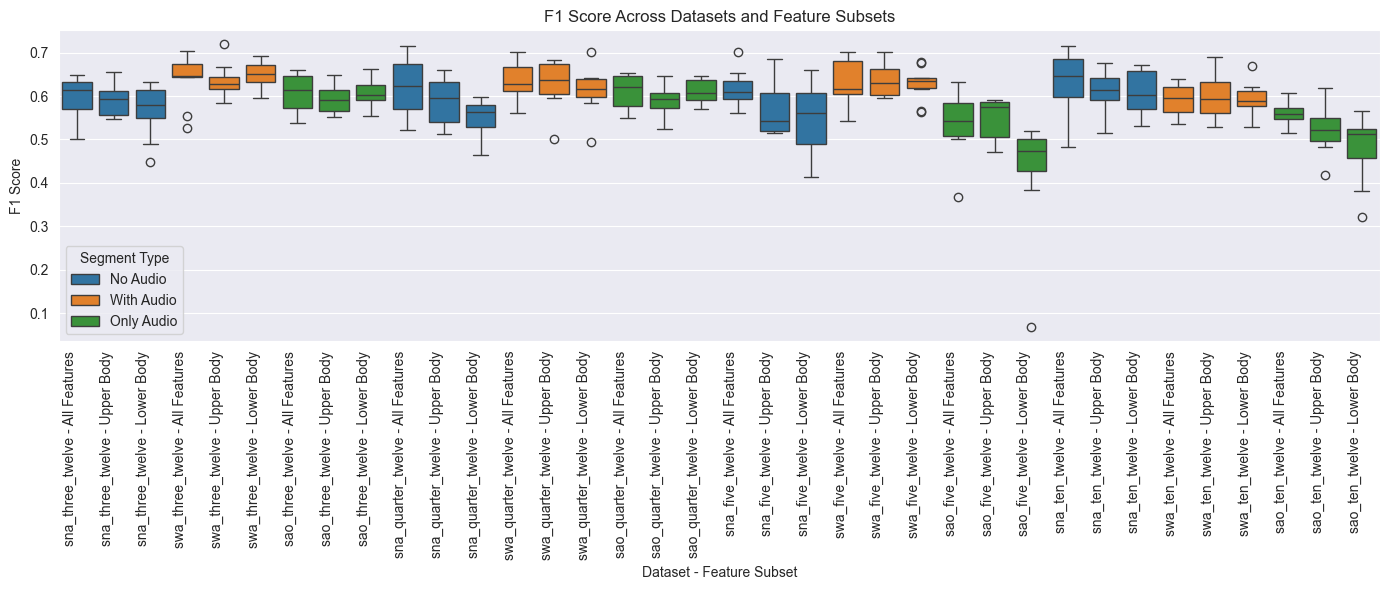

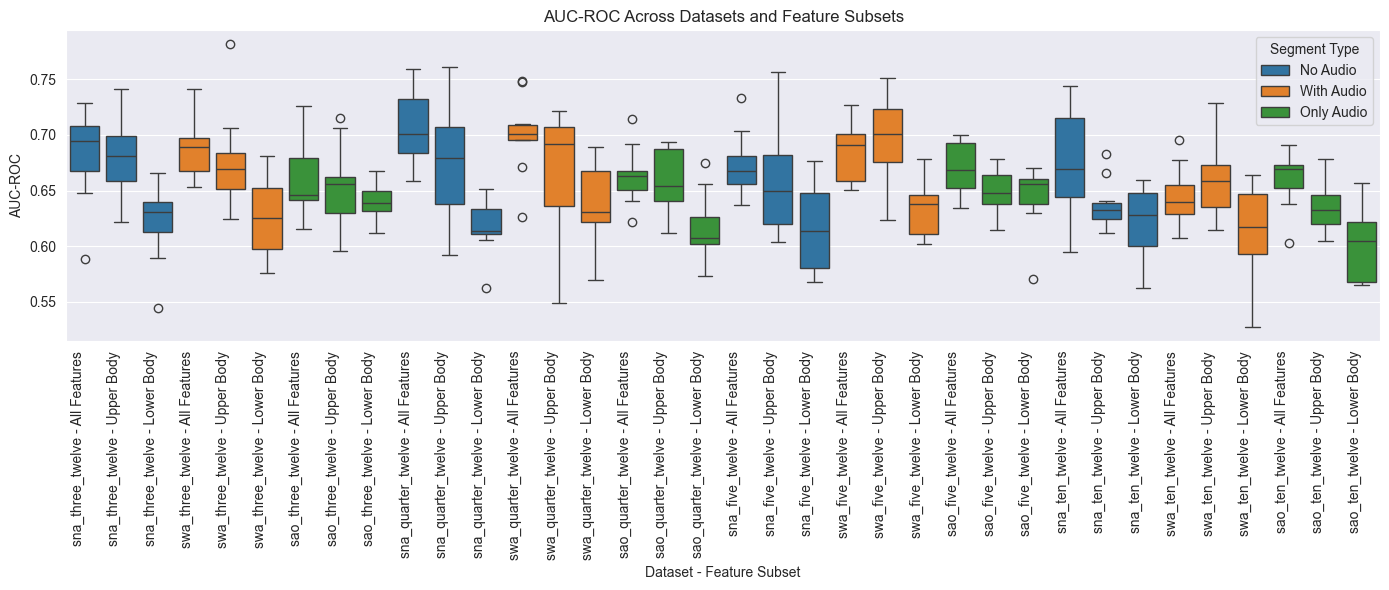

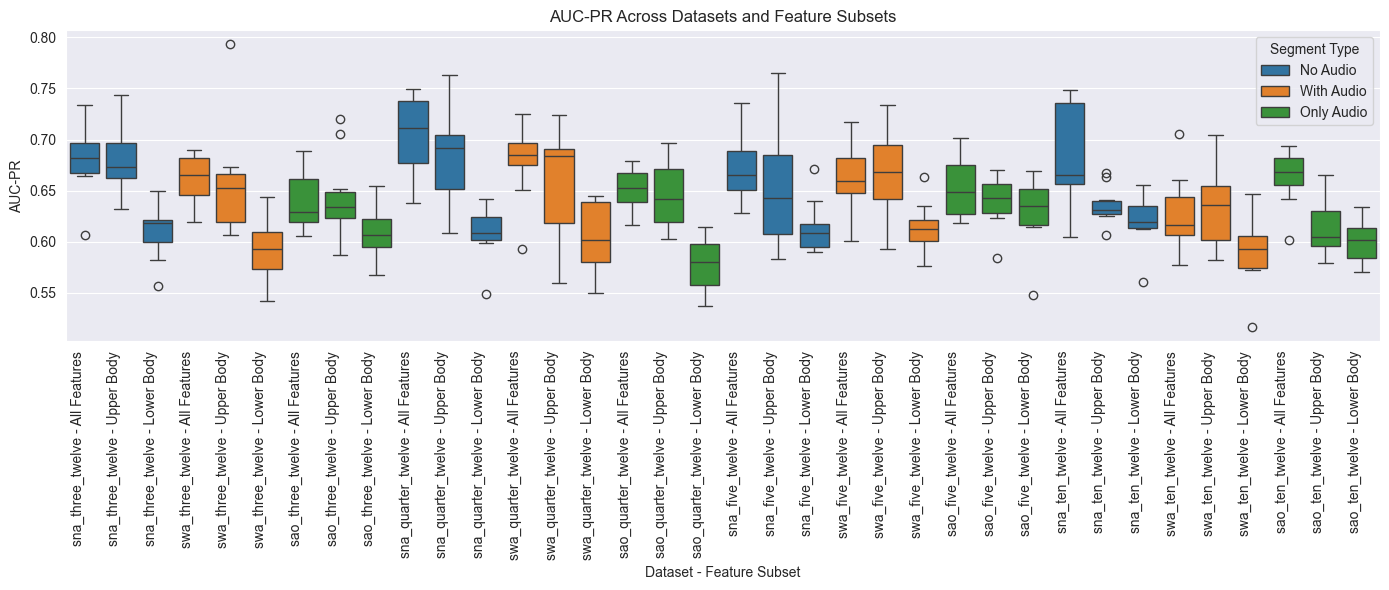

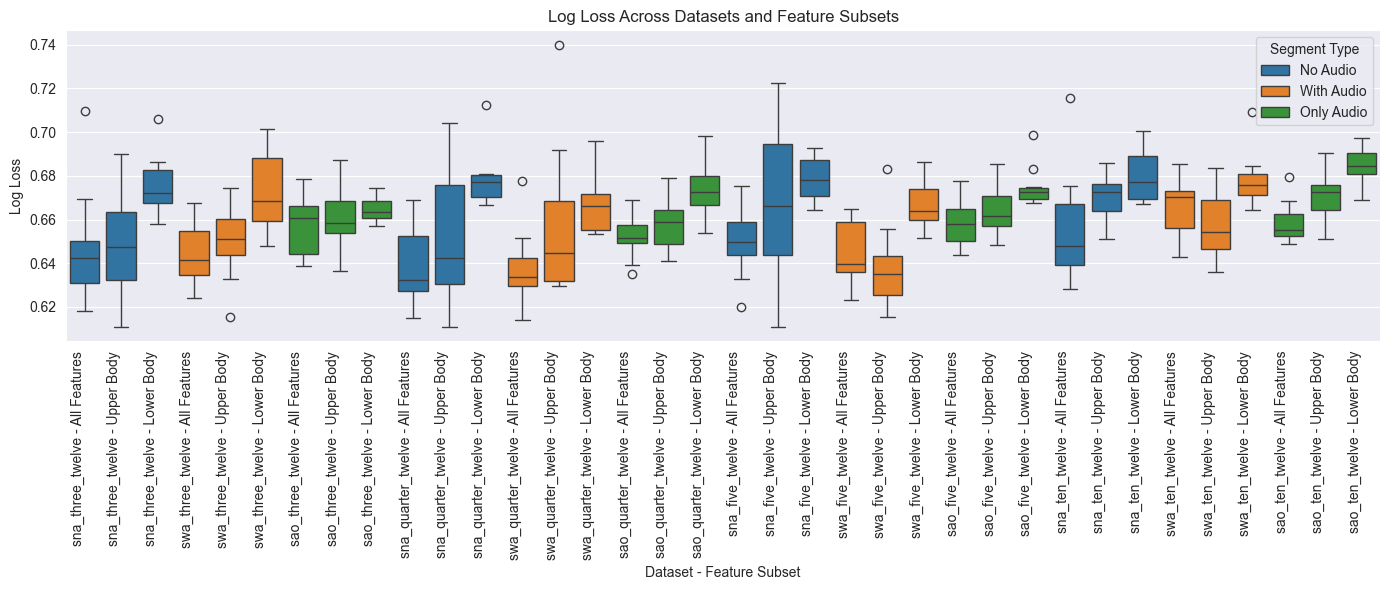

In [27]:

summary_results = []

# Loop through all feature datasets
for n, d in dataset_results_gap_ff.items():
    s = dataset_results_gap_ff[n]

    # Determine modality label for plotting
    if "wa" in n:
        label_base = "With Audio"
    elif "na" in n:
        label_base = "No Audio"
    else:
        label_base = "Only Audio"

    # Define different feature subsets to test
    configs = [
        ("ff_all", [], "All Features"),
        ("ff_upper", [0, 1, 7, 8, 9, 10, 11], "Upper Body"),
        ("ff_lower", [2, 3, 4, 5, 6], "Lower Body")
    ]

    for suffix, mask, feat_label in configs:
        save_name = f"{n}_{suffix}"
        label = f"{label_base} - {feat_label}"

        # Train model and collect metrics
        metrics = train_model(s['xs'], s['ys'], s['agent_ids'], 10, label, feature_names, save_name, mask)

        # Store each metric result into summary_results
        for metric_name, values in metrics.items():
            for v in values:
                summary_results.append({
                    'Dataset': n,
                    'Segment Type': label_base,
                    'Feature Subset': feat_label,
                    'Metric': metric_name,
                    'Score': v
                })

print("✅ Model training and metric collection complete.")

# Convert to DataFrame
df_summary = pd.DataFrame(summary_results)

# Save raw metrics to CSV
df_summary.to_csv("all_model_metrics_summary.csv", index=False)

# Display a pivot table of mean scores
df_means = df_summary.groupby(['Segment Type', 'Feature Subset', 'Metric'])['Score'].mean().reset_index()
df_means_pivot = df_means.pivot_table(index=['Segment Type', 'Feature Subset'], columns='Metric', values='Score')
display(df_means_pivot)

# Prepare x-axis label by combining dataset + feature subset
df_summary['Dataset-Features'] = df_summary['Dataset'] + " - " + df_summary['Feature Subset']

# Sort order for consistent plots
dataset_order = sorted(df_summary['Dataset-Features'].unique())

# Plot metrics separately
metrics_to_plot = df_summary['Metric'].unique()
for metric in metrics_to_plot:
    plt.figure(figsize=(14, 6))
    subset = df_summary[df_summary['Metric'] == metric]
    sns.boxplot(data=subset, x="Dataset-Features", y="Score", hue="Segment Type")
    plt.title(f"{metric} Across Datasets and Feature Subsets")
    plt.xticks(rotation=90, ha='right')
    plt.ylabel(metric)
    plt.xlabel("Dataset - Feature Subset")
    plt.tight_layout()
    plt.show()


In [133]:
def find_incomplete_rows_with_valid_previous_loop(df, keypoint_labels):
    bad_rows = []

    # Loop over each keypoint label
    for label in keypoint_labels:
        for i in range(1, len(df)):  # start from 1 to always have a previous row
            curr = df.iloc[i]
            prev = df.iloc[i - 1]

            # Skip if video_id or agent_id don't match (not a continuous sequence)
            if curr['video_id'] != prev['video_id'] or curr['agent_id'] != prev['agent_id']:
                continue

            # Skip if current keypoint is present or if somehow i == 0 (redundant check)
            if curr[keypoint_labels[label]] is not None or i == 0:
                continue

            # Skip if the previous frame also had missing data (we only want first dropout)
            if prev[keypoint_labels[label]] is None:
                continue

            # This is a "bad" row: current is None but previous was valid
            bad_rows.append(i)

    # Return the DataFrame slice with all detected problematic rows
    return df.iloc[bad_rows]

# Example usage to display bad rows
display(find_incomplete_rows_with_valid_previous_loop(fdf, keypoints_labels))


,Unnamed: 0,video_id,camera_id,frame_id,agent_id,num_kp,occluded,is_laughing_no_audio,is_laughing_only_audio,is_laughing_with_audio,...,leftElbow,leftWrist,rightHip,rightKnee,rightAnkle,leftHip,leftKnee,leftAnkle,rightFoot,leftFoot


,Dataset,Segment Type,Feature Subset,Metric,Dataset-Features,Score
0,swa_three_twelve,With Audio,All Features,F1 Score,swa_three_twelve - All Features,0.638438
1,swa_three_twelve,With Audio,Lower Body,F1 Score,swa_three_twelve - Lower Body,0.651214
2,swa_three_twelve,With Audio,Upper Body,F1 Score,swa_three_twelve - Upper Body,0.634716


C:\Users\Vassil.Guenov\AppData\Local\Temp\ipykernel_34536\3202070566.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, group_keys=False).apply(filter_group)
C:\Users\Vassil.Guenov\AppData\Local\Temp\ipykernel_34536\3202070566.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, rotation=45, ha='right')


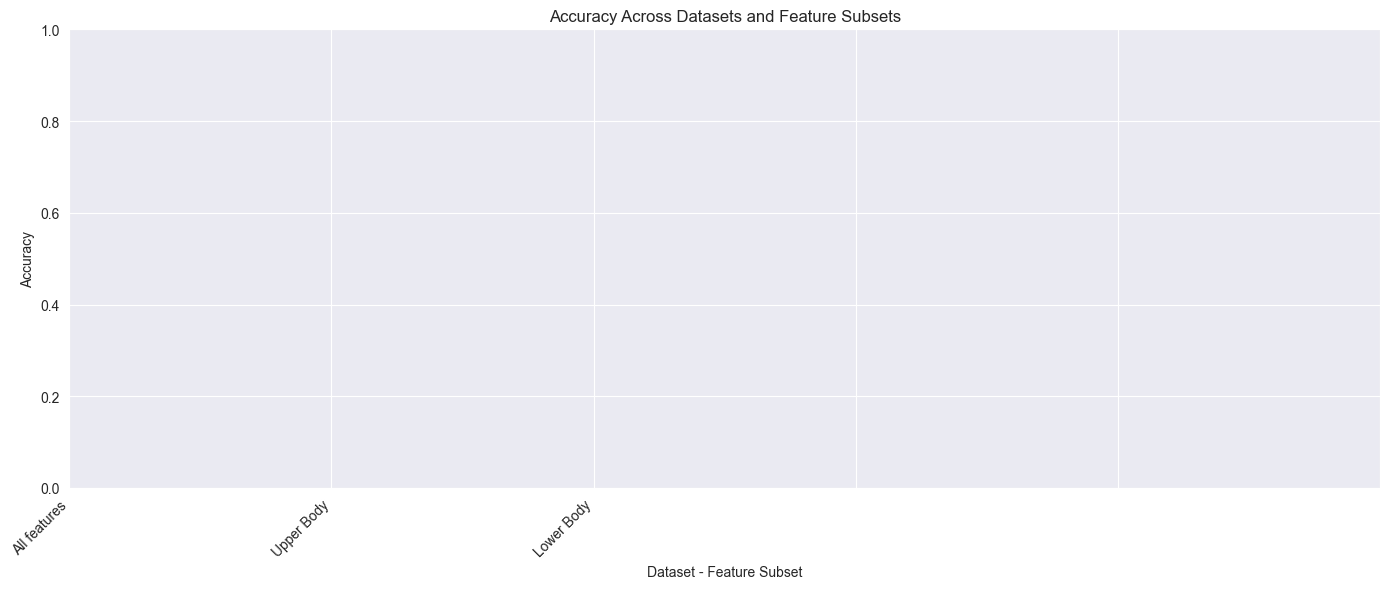

C:\Users\Vassil.Guenov\AppData\Local\Temp\ipykernel_34536\3202070566.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, rotation=45, ha='right')


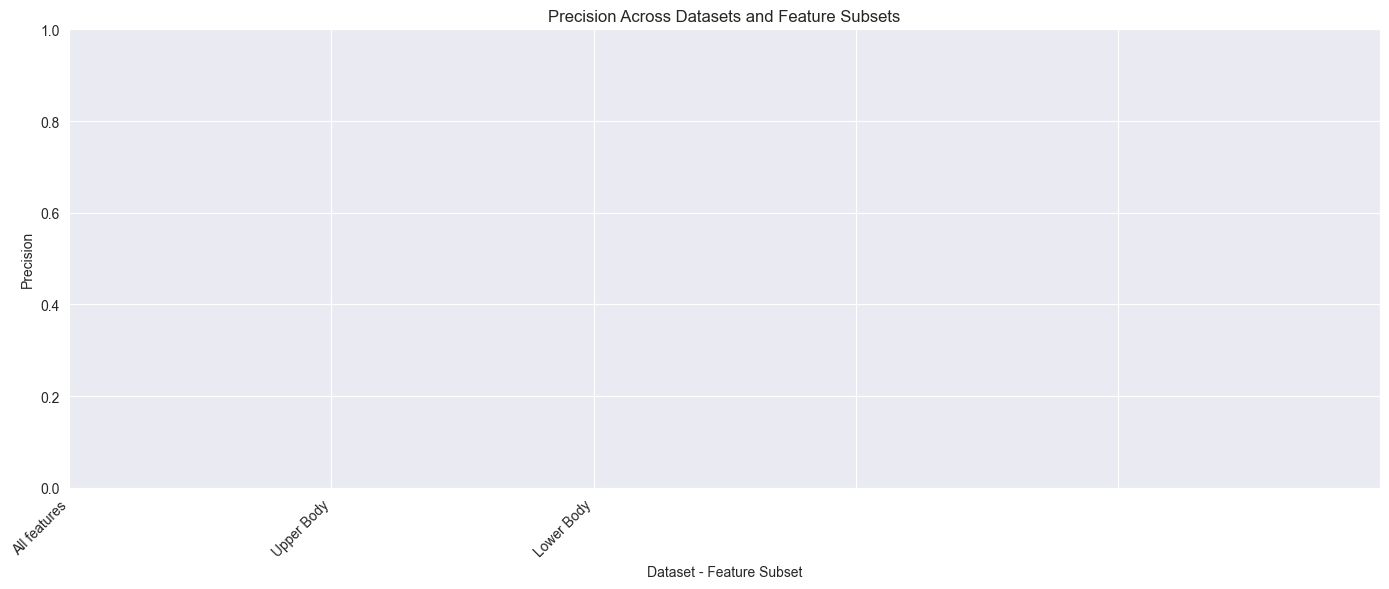

C:\Users\Vassil.Guenov\AppData\Local\Temp\ipykernel_34536\3202070566.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, rotation=45, ha='right')


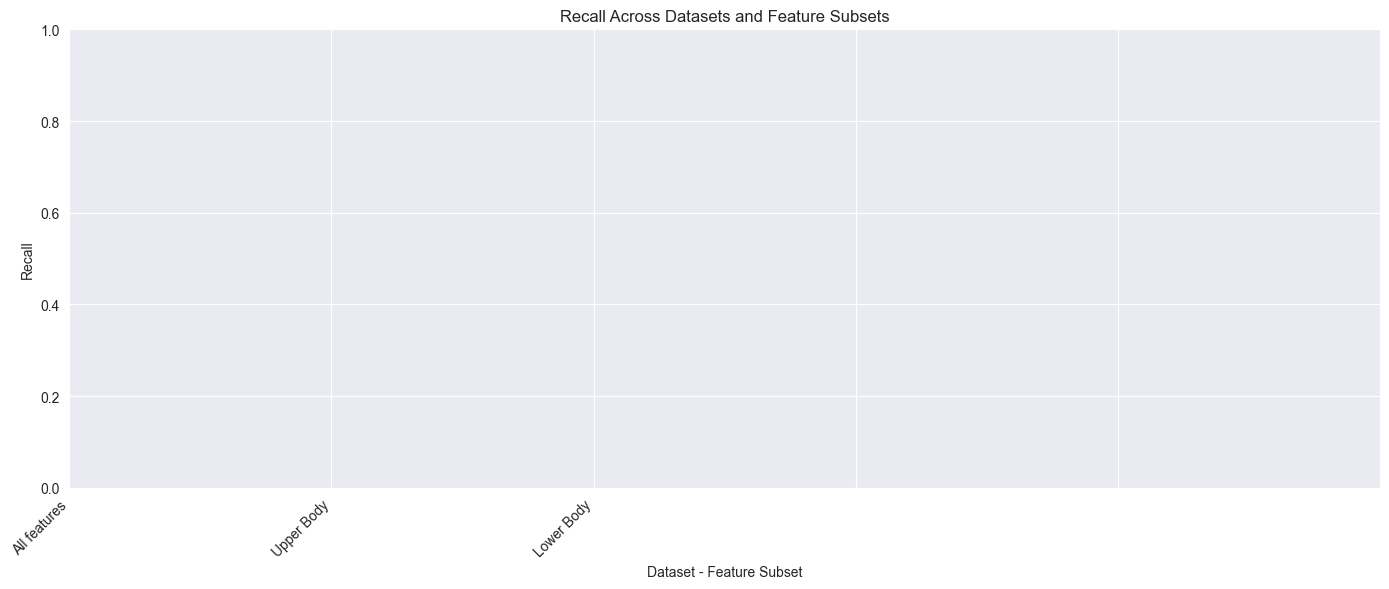

C:\Users\Vassil.Guenov\AppData\Local\Temp\ipykernel_34536\3202070566.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, rotation=45, ha='right')


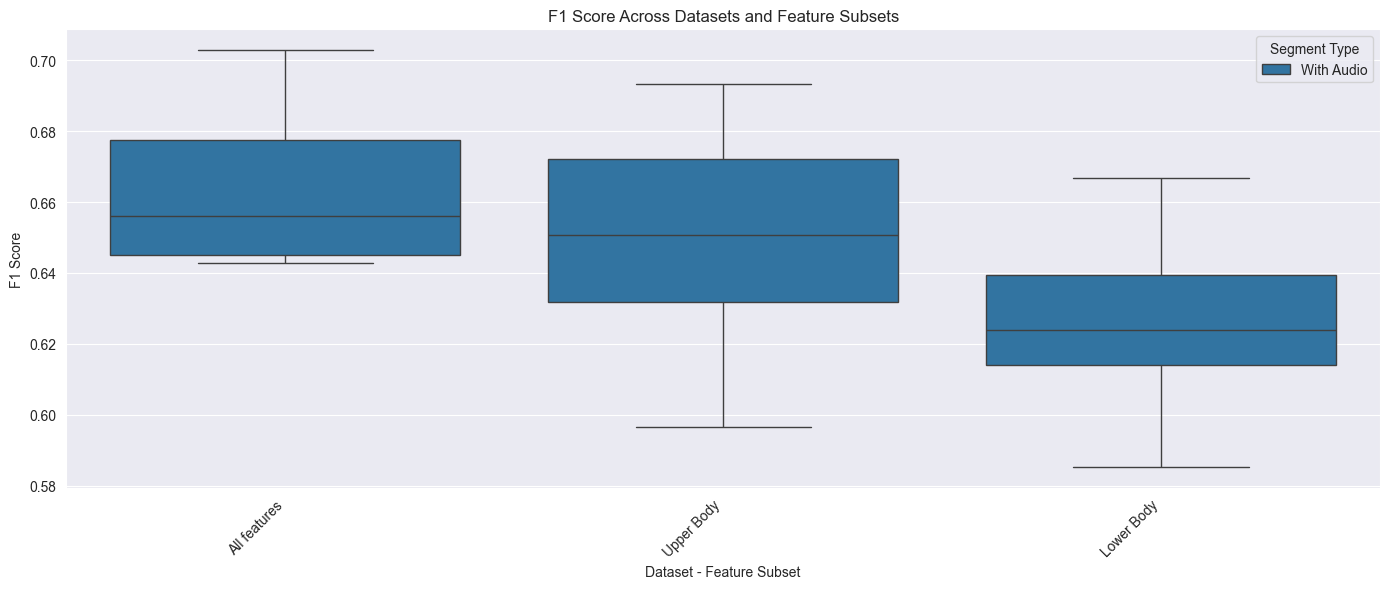

C:\Users\Vassil.Guenov\AppData\Local\Temp\ipykernel_34536\3202070566.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, rotation=45, ha='right')


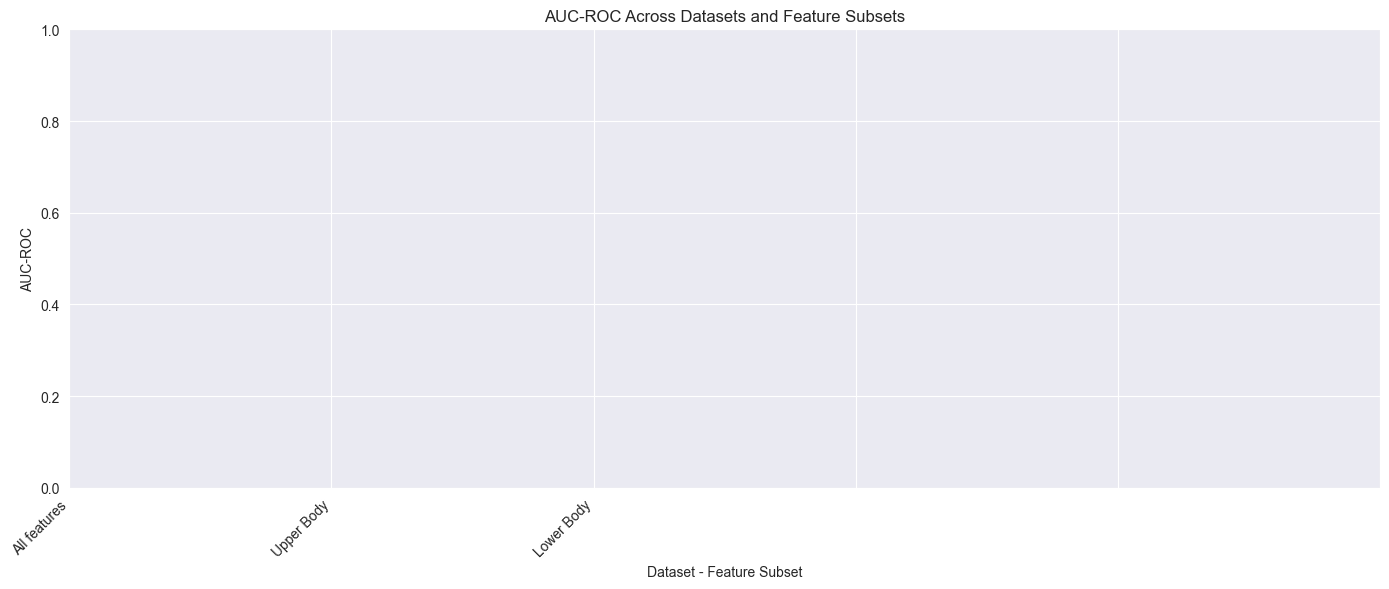

C:\Users\Vassil.Guenov\AppData\Local\Temp\ipykernel_34536\3202070566.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, rotation=45, ha='right')


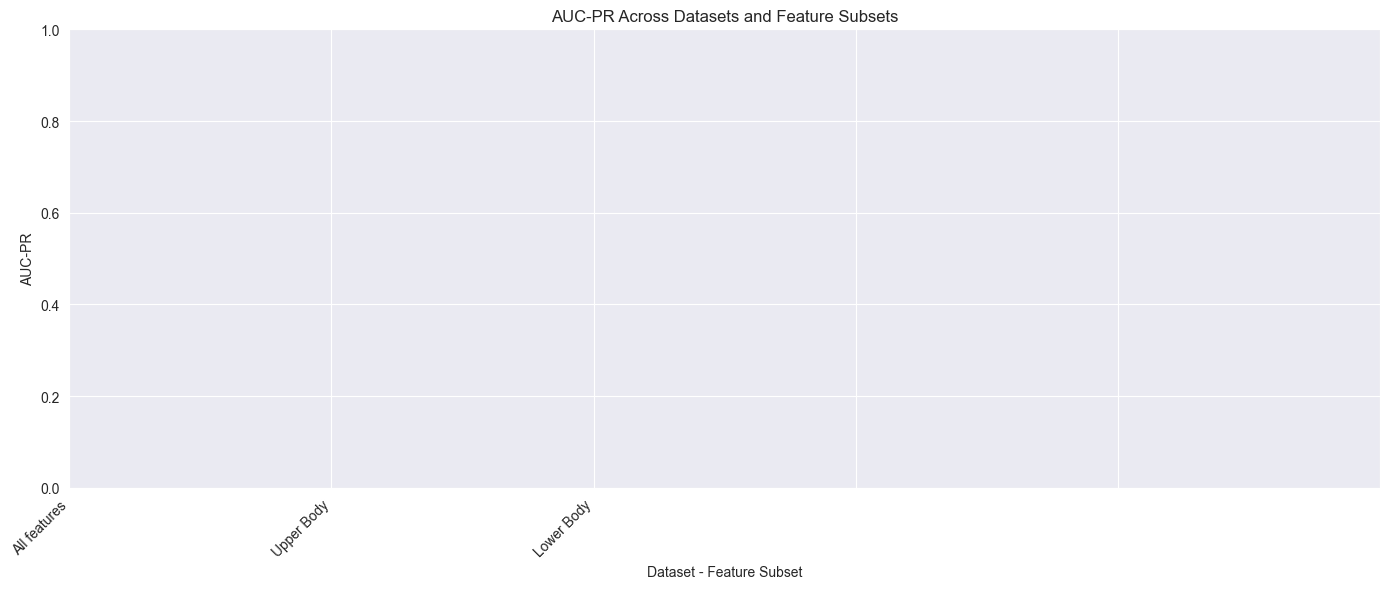

C:\Users\Vassil.Guenov\AppData\Local\Temp\ipykernel_34536\3202070566.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, rotation=45, ha='right')


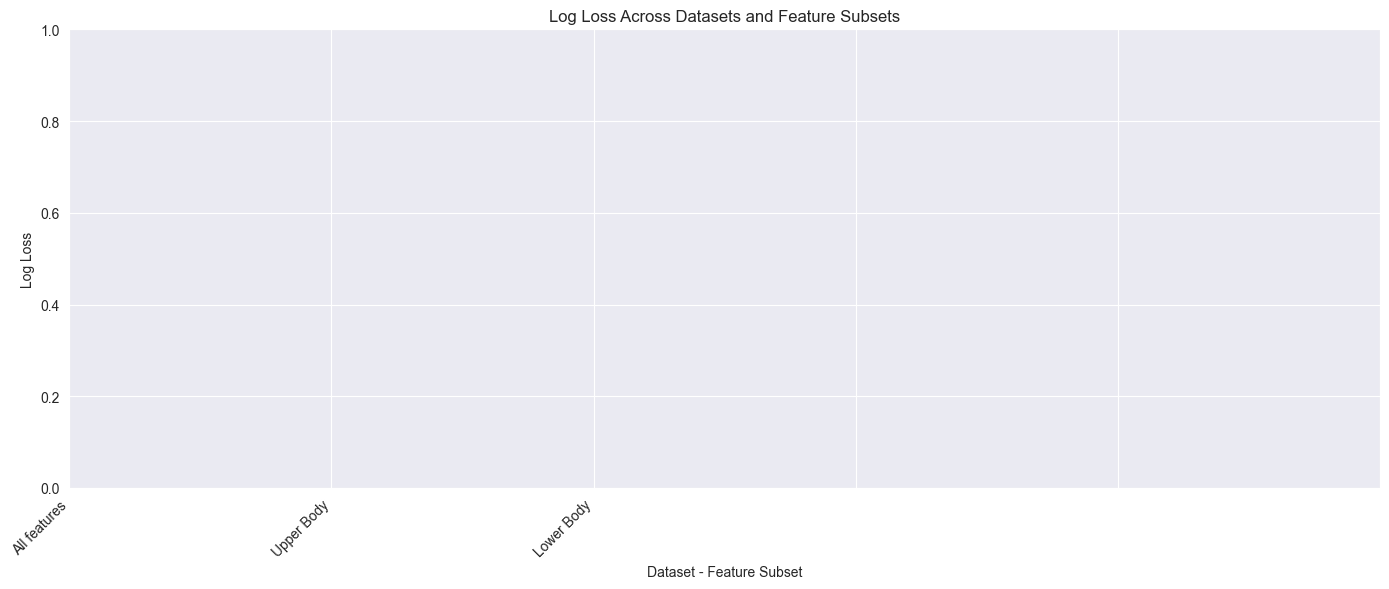

In [75]:
df_filtered = df_summary[~df_summary['Dataset'].isin(["sao_ten_twelve", "swa_ten_twelve", "sna_ten_twelve"])]
df_filtered = df_filtered[~(df_filtered['Metric'] == 'Log Loss')]
df_filtered = df_filtered[~(df_filtered['Metric'] == 'AUC-PR')]
df_filtered = df_filtered[~(df_filtered['Metric'] == 'AUC-ROC')]
df_filtered = df_filtered[(df_filtered['Dataset'] == 'swa_three_twelve')]
df_filtered = df_filtered[(df_filtered['Metric'] == 'F1 Score')]
average_results = df_filtered.groupby(
    ['Dataset', 'Segment Type', 'Feature Subset', 'Metric', 'Dataset-Features'],
    as_index=False
)['Score'].mean()
display(average_results)


def remove_outliers_iqr(df, group_cols, value_col):
    def filter_group(group):
        q1 = group[value_col].quantile(0.25)
        q3 = group[value_col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        return group[(group[value_col] >= lower_bound) & (group[value_col] <= upper_bound)]

    return df.groupby(group_cols, group_keys=False).apply(filter_group)

# Apply IQR-based outlier removal for the F1 Score metric
df_no_outliers = remove_outliers_iqr(
    df_filtered,
    group_cols=['Dataset', 'Segment Type', 'Feature Subset'],
    value_col='Score'
)

custom_labels = [
      # for Fixed segmentation
    "All features", "Upper Body", "Lower Body"            # for 5-second segmentation
]

# Ensure the number of labels matches the number of x-ticks
for metric in metrics_to_plot:
    plt.figure(figsize=(14, 6))
    subset = df_no_outliers[df_no_outliers['Metric'] == metric]
    ax = sns.boxplot(data=subset, x="Dataset-Features", y="Score", hue="Segment Type")
    plt.title(f"{metric} Across Datasets and Feature Subsets")

    # Apply custom labels
    ax.set_xticklabels(custom_labels, rotation=45, ha='right')

    plt.ylabel(metric)
    plt.xlabel("Dataset - Feature Subset")
    plt.tight_layout()
    plt.show()